Running simulation for Order k=4...


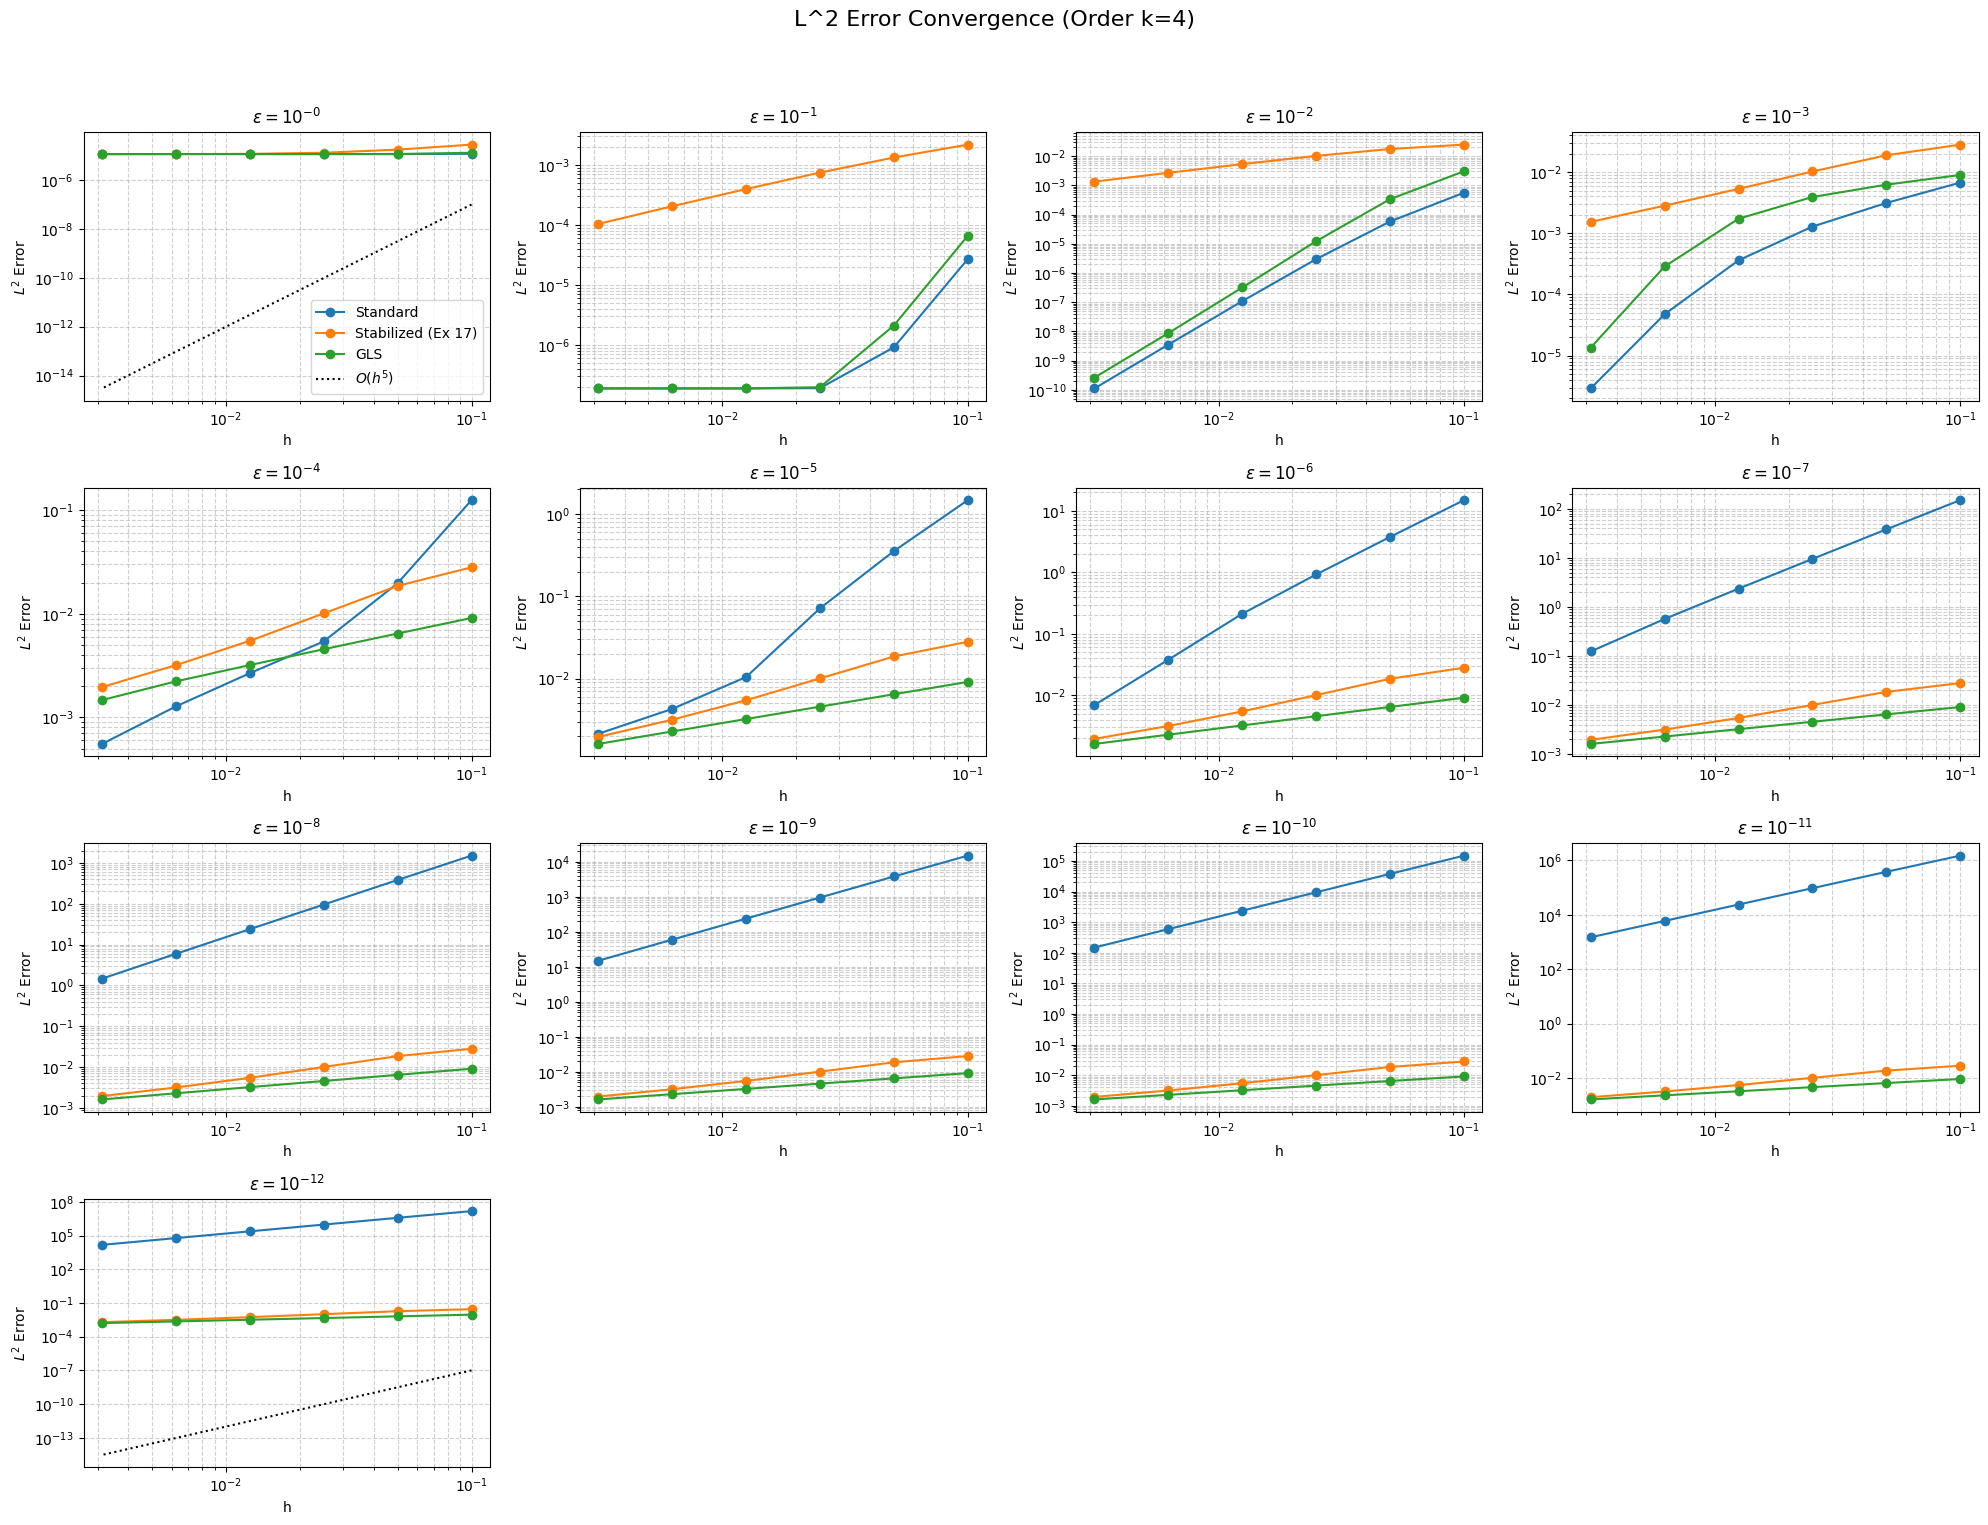

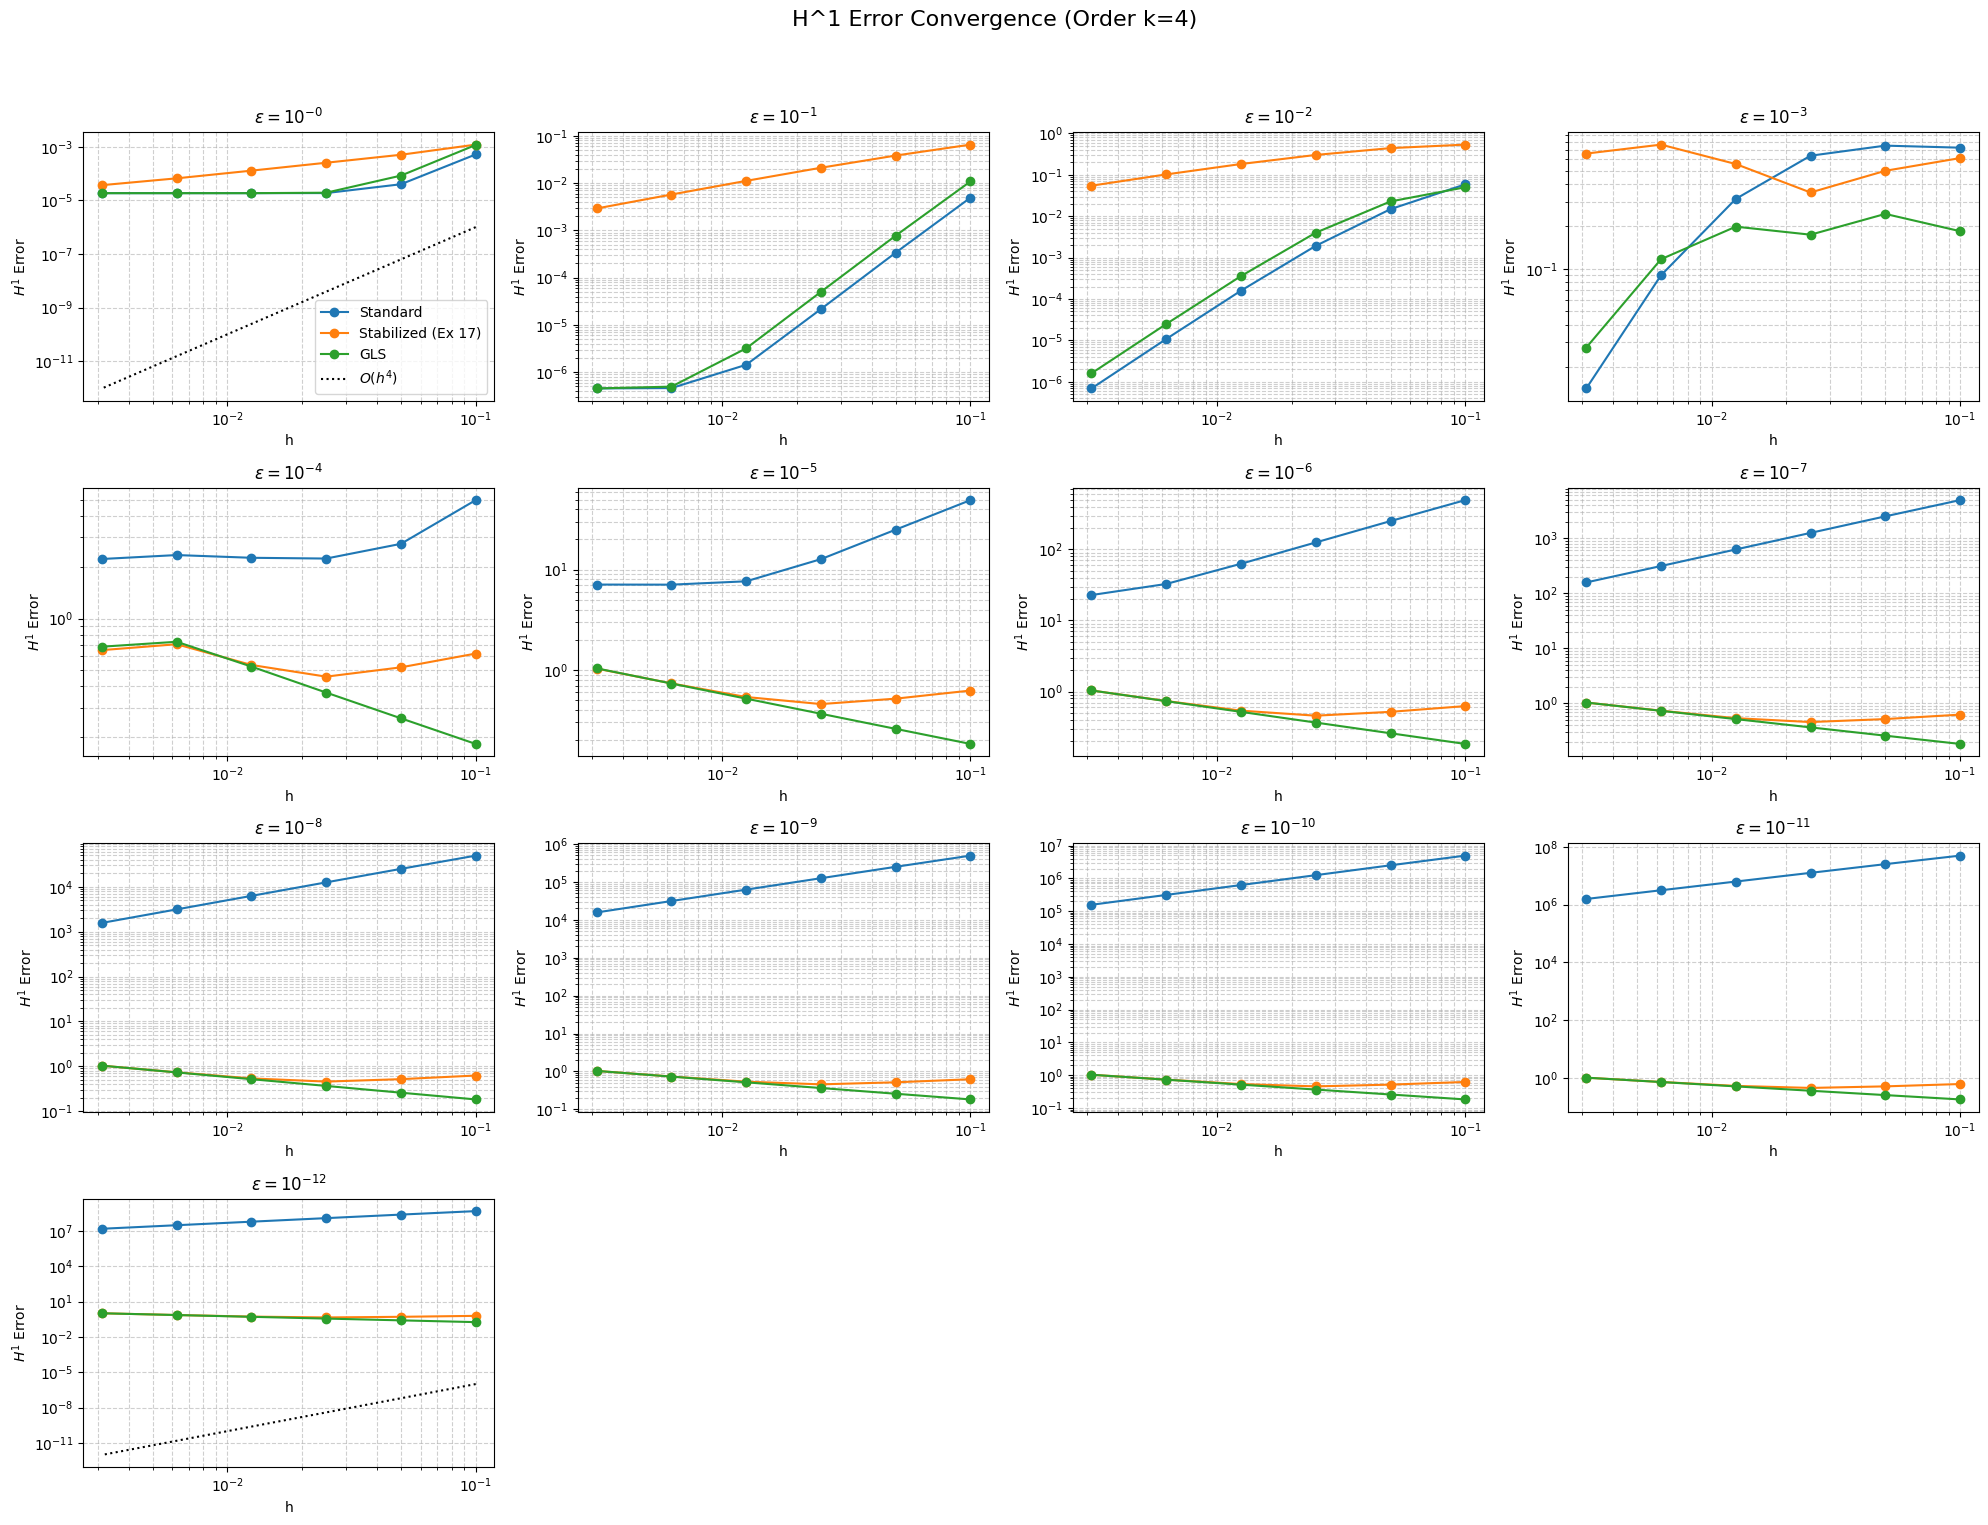

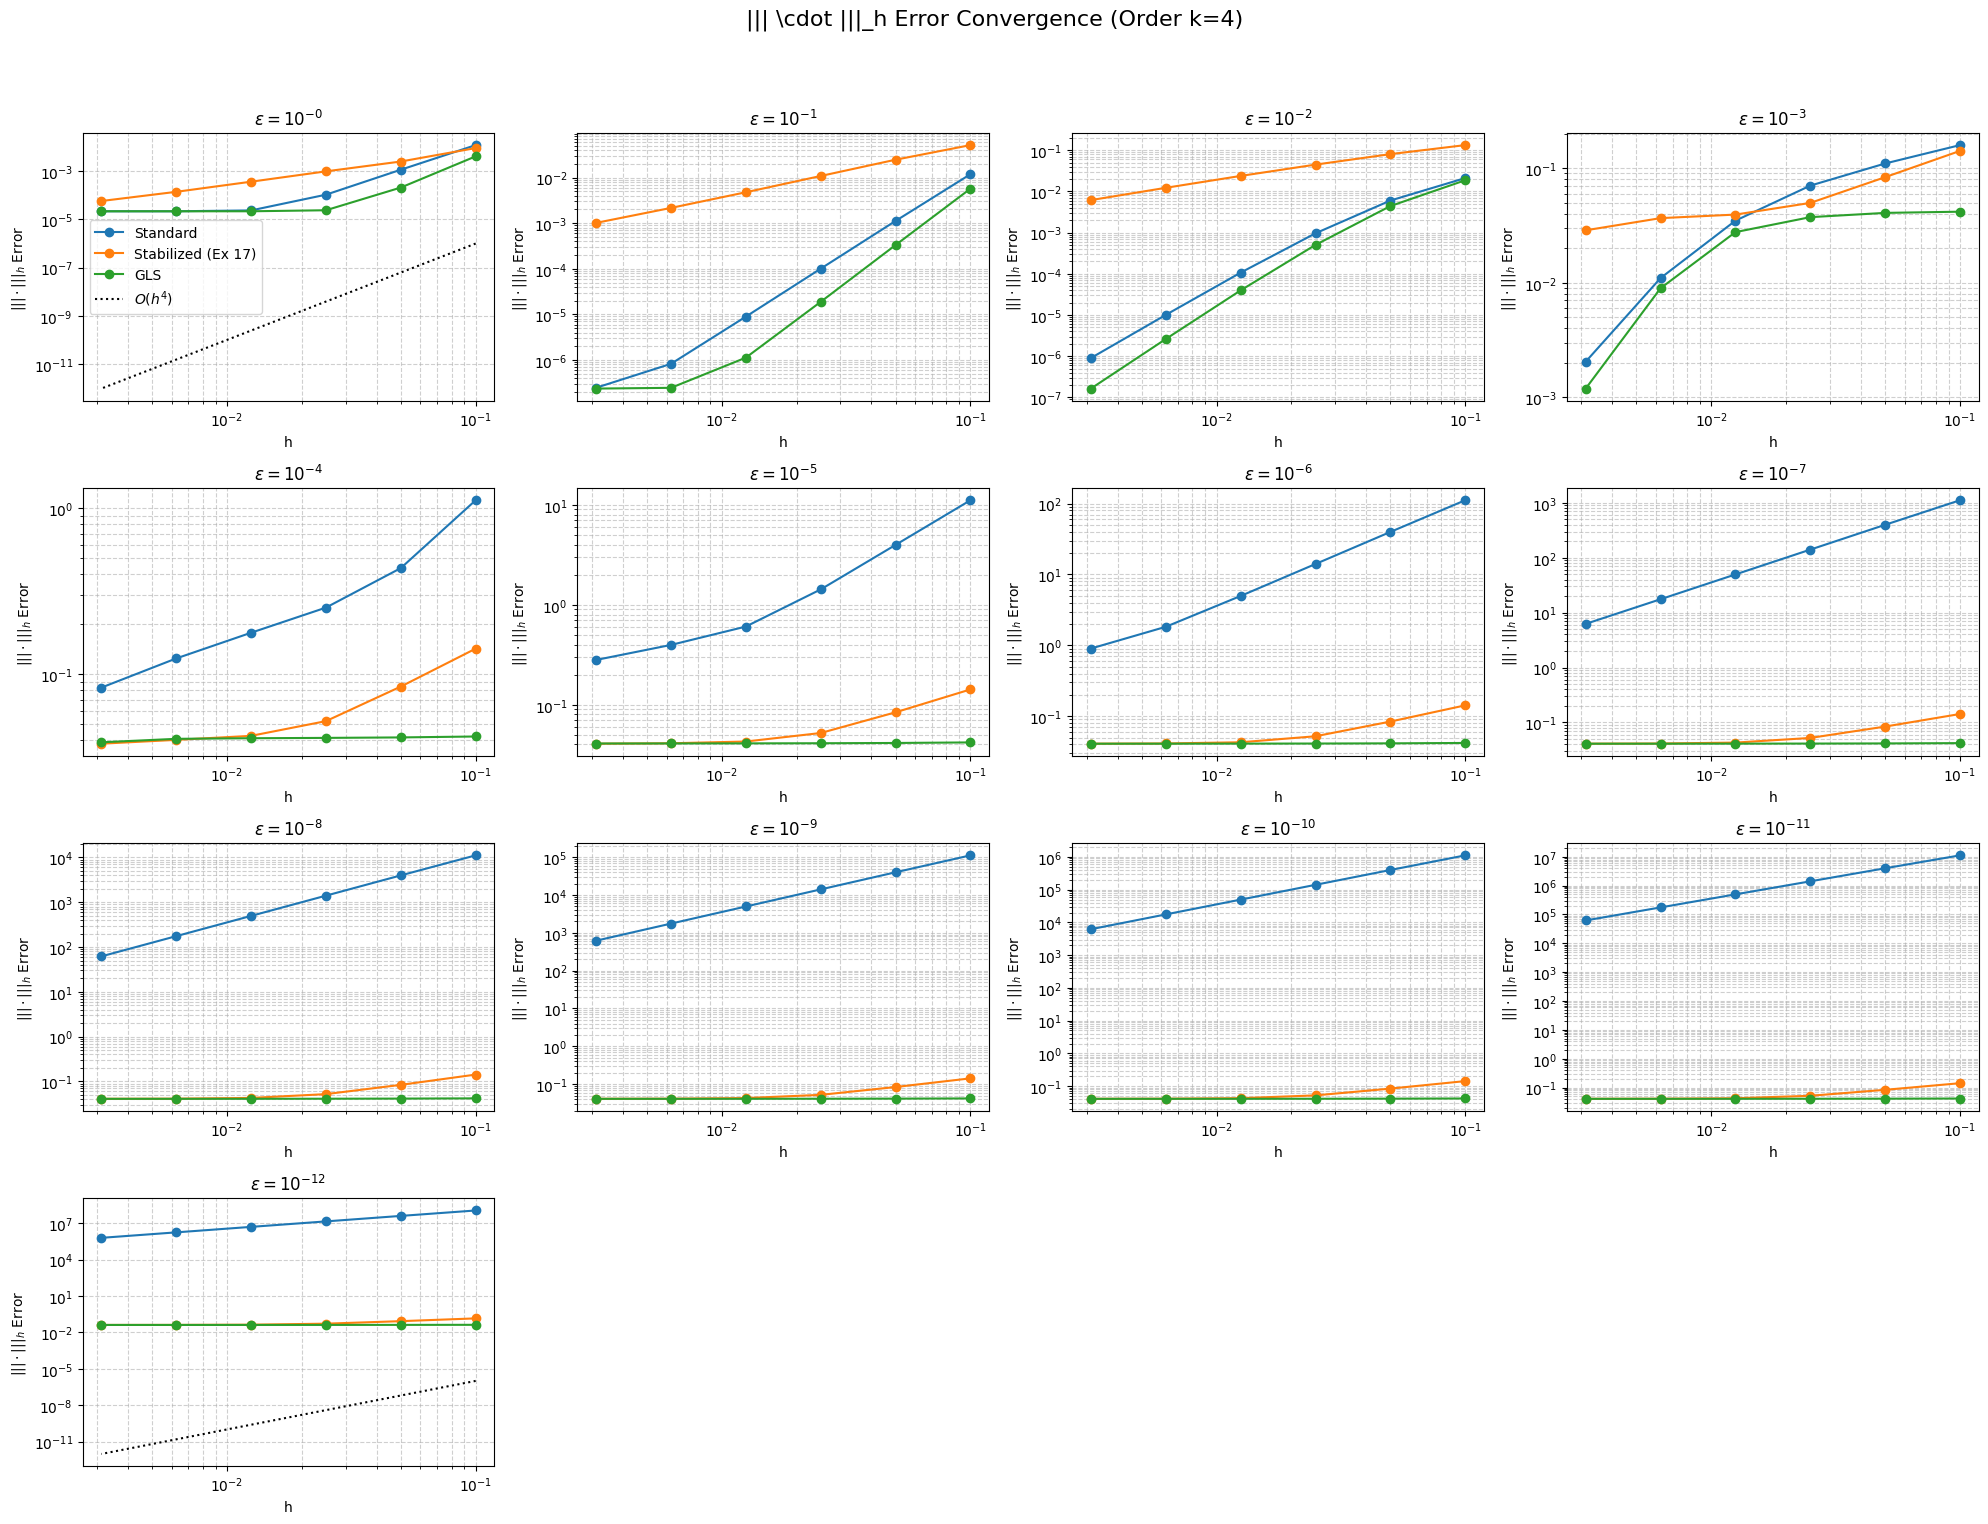

In [1]:
from ngsolve import *
from ngsolve.meshes import Make1DMesh
import numpy as np
import matplotlib.pyplot as plt


# 1. Exact Solution Setup

def ExactSolution(eps):
    K = 11 * np.pi
    denom = 1 + (eps * K)**2
    A = eps / denom
    B = -1 / (K * denom)
    
    # Stable calculation for boundary layer term
    exp_term = exp( (x-1)/eps )
    term_homog = -B + 2*B * exp_term 
    
    u_exact = term_homog + A * sin(K*x) + B * cos(K*x)
    return u_exact


# 2. Solver Implementation

def SolveAdvectionDiffusion(epsilon, N, order, method):
    mesh = Make1DMesh(N)
    fes = H1(mesh, order=order, dirichlet="left|right")
    u, v = fes.TnT()
    
    beta_vec = 1.0 
    f_source = sin(11 * np.pi * x)
    h = 1.0 / N
    
    # Standard Forms
    a = BilinearForm(fes)
    a += (epsilon * grad(u) * grad(v) + beta_vec * grad(u) * v) * dx
    f = LinearForm(fes)
    f += f_source * v * dx
    
    # --- METHOD SPECIFIC TERMS ---
    if method == "Stabilized (Ex 17)":
        art_diff = 0.5 * h 
        a += art_diff * grad(u) * grad(v) * dx
        
    elif method == "GLS":
        tau = h / (2 * abs(beta_vec))
        
        # Hessian for second derivative u_xx
        u_xx = u.Operator("hesse")[0]
        v_xx = v.Operator("hesse")[0]
        
        # Strong form operators
        Lu = -epsilon * u_xx + beta_vec * grad(u)[0]
        Lv = -epsilon * v_xx + beta_vec * grad(v)[0]
        
        a += tau * Lu * Lv * dx
        f += tau * f_source * Lv * dx

    a.Assemble()
    f.Assemble()
    gfu = GridFunction(fes)
    gfu.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec
    
    return gfu, mesh


# 3. Simulation & Data Collection

epsilons = [10**(-i) for i in range(13)]
methods = ["Standard", "Stabilized (Ex 17)", "GLS"]
mesh_sizes = [10, 20, 40, 80, 160, 320]
rate = 4 

# Dictionaries to store results
results_L2 = {eps: {m: [] for m in methods} for eps in epsilons}
results_H1 = {eps: {m: [] for m in methods} for eps in epsilons}
results_GLS_Norm = {eps: {m: [] for m in methods} for eps in epsilons}

print(f"Running simulation for Order k={rate}...")

for eps in epsilons:
    for m in methods:
        errs_l2 = []
        errs_h1 = []
        errs_gls_norm = []
        
        for N in mesh_sizes:
            try:
                gfu, mesh = SolveAdvectionDiffusion(eps, N, rate, m)
                u_ex = ExactSolution(eps)
                h_val = 1.0/N
                
                # --- 1. L2 Error ---
                diff_sq = (gfu - u_ex)**2
                l2_sq = Integrate(diff_sq, mesh)
                errs_l2.append(sqrt(l2_sq))
                
                # --- 2. H1 Error Term ---
                grad_u_ex = CF((u_ex.Diff(x),))
                diff_grad_sq = (grad(gfu) - grad_u_ex)**2
                h1_sq = Integrate(diff_grad_sq, mesh)
                errs_h1.append(sqrt(h1_sq))
                
                # --- 3. GLS Norm Error (Exercise 20d) ---
                # ||v||_h^2 = ||v||^2 + eps*||grad v||^2 + sum tau*||L v - f||^2
                # Here v is the error (u - u_h).
                # Since L u = f, L(u - u_h) = f - L u_h = Residual.
                
                beta = 1.0
                tau = h_val / (2*beta)
                
                # Calculate Residual: f - (-eps*u_xx + beta*u_x)
                # Note: gfu.Operator("hesse")[0] is the second derivative
                u_h_xx = gfu.Operator("hesse")[0]
                u_h_x = grad(gfu)[0]
                
                f_val = sin(11 * np.pi * x)
                L_uh = -eps * u_h_xx + beta * u_h_x
                residual = f_val - L_uh
                
                res_sq = Integrate(tau * residual**2, mesh)
                
                # Combine parts for GLS Norm
                # norm^2 = l2^2 + eps * h1^2 + res^2
                gls_norm_sq = l2_sq + eps * h1_sq + res_sq
                errs_gls_norm.append(sqrt(gls_norm_sq))
                
            except Exception as e:
                errs_l2.append(float('nan'))
                errs_h1.append(float('nan'))
                errs_gls_norm.append(float('nan'))
        
        results_L2[eps][m] = errs_l2
        results_H1[eps][m] = errs_h1
        results_GLS_Norm[eps][m] = errs_gls_norm


# 4. Plotting Function

def PlotGrid(results_dict, norm_name, ref_order):
    rows = 4
    cols = 4
    fig, axs = plt.subplots(rows, cols, figsize=(20, 16))
    fig.suptitle(f"{norm_name} Error Convergence (Order k={rate})", fontsize=16)
    
    axs_flat = axs.flatten()
    h_values = [1/N for N in mesh_sizes]

    for i, eps in enumerate(epsilons):
        ax = axs_flat[i]
        
        for m in methods:
            errs = results_dict[eps][m]
            if not all(np.isnan(errs)):
                ax.loglog(h_values, errs, 'o-', label=m)
        
        ax.set_title(f"$\epsilon = 10^{{-{i}}}$")
        ax.set_xlabel("h")
        ax.set_ylabel(f"${norm_name}$ Error")
        ax.grid(True, which="both", linestyle='--', alpha=0.6)
        
        if i == 0 or i == 12:
            ref = [1e-2 * h**ref_order for h in h_values]
            ax.loglog(h_values, ref, 'k:', label=f'$O(h^{{{ref_order}}})$')
        
        if i == 0:
            ax.legend()

    for j in range(len(epsilons), rows*cols):
        axs_flat[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# 5. Generate All Plots


# 1. L2 Error (Reference: k+1 = 5)
PlotGrid(results_L2, "L^2", rate + 1)

# 2. H1 Error (Reference: k = 4)
PlotGrid(results_H1, "H^1", rate)

# 3. GLS Norm Error (Exercise 20d)
# Reference: Typically O(h^k) or O(h^{k+0.5}) depending on regime
PlotGrid(results_GLS_Norm, "||| \cdot |||_h", rate)